In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
df= pd.read_csv("/content/heart.csv")

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

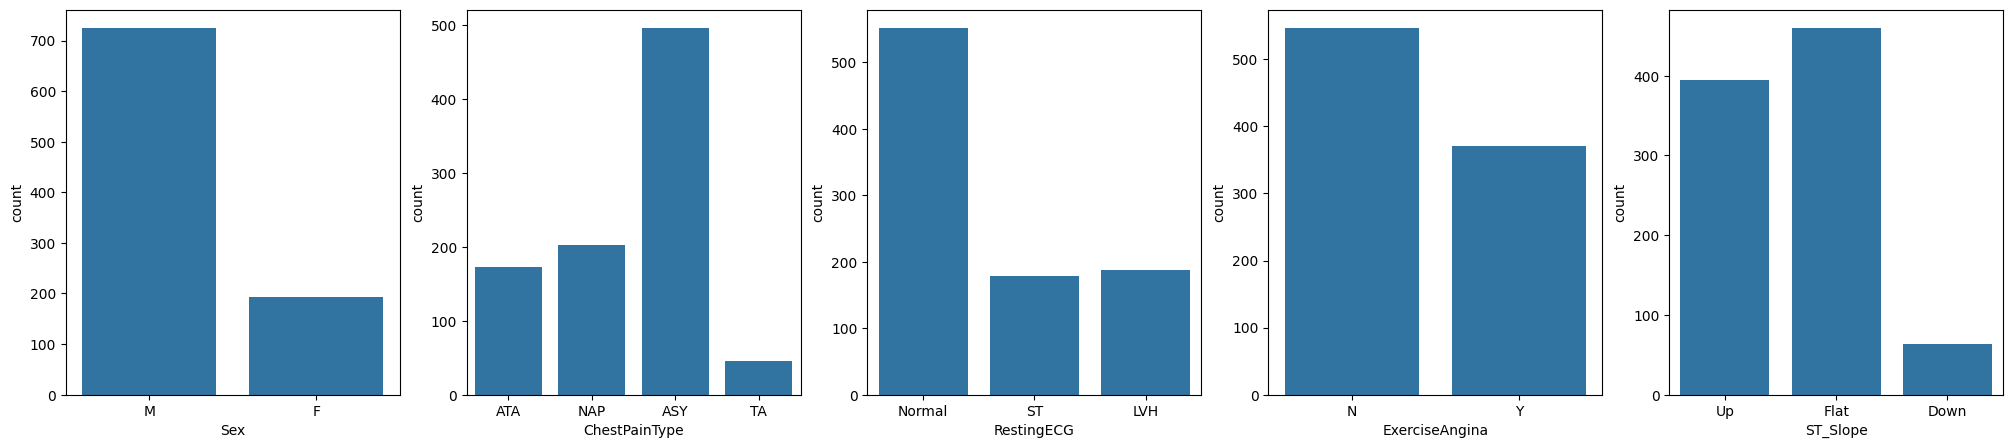

In [8]:
cat=['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
plt.figure(figsize=(25,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  sns.countplot(x=cat[i],data=df)

In [9]:
df[df.HeartDisease == 1]['Sex'].value_counts()

,count
Sex,
M,458
F,50


Text(0.5, 1.0, 'ChestPainType')

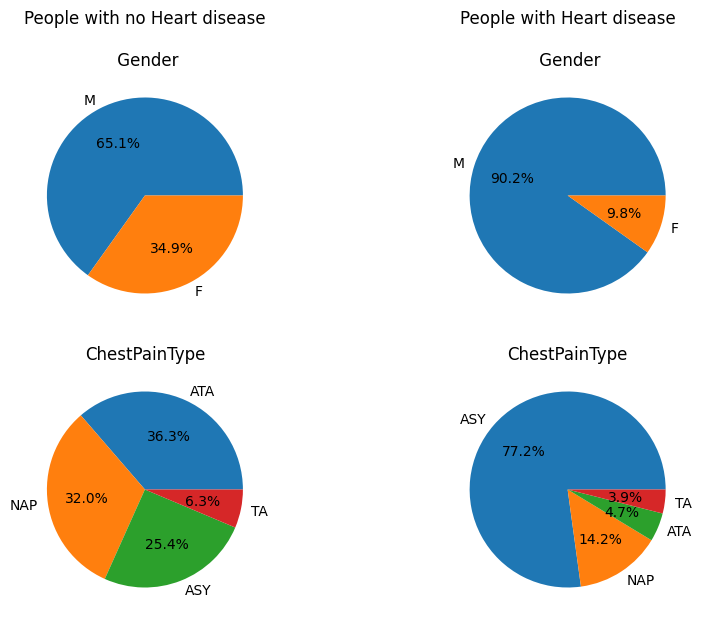

In [10]:
fig,axs = plt.subplots(2,2,figsize = (10,7))
axs[0, 0].pie( df[df.HeartDisease == 0]['Sex'].value_counts(), labels= df[df.HeartDisease == 0]['Sex'].value_counts().index, autopct='%1.1f%%')
axs[0, 1].pie( df[df.HeartDisease == 1]['Sex'].value_counts(), labels= df[df.HeartDisease == 1]['Sex'].value_counts().index, autopct='%1.1f%%')
axs[0,0].set_title("People with no Heart disease\n\n Gender")
axs[0,1].set_title("People with Heart disease\n\n Gender")
axs[1, 0].pie( df[df.HeartDisease == 0]['ChestPainType'].value_counts(), labels= df[df.HeartDisease == 0]['ChestPainType'].value_counts().index, autopct='%1.1f%%')
axs[1, 1].pie( df[df.HeartDisease == 1]['ChestPainType'].value_counts(), labels= df[df.HeartDisease == 1]['ChestPainType'].value_counts().index, autopct='%1.1f%%')
axs[1,0].set_title("ChestPainType")
axs[1,1].set_title("ChestPainType")

Text(0.5, 1.0, 'FastingBS')

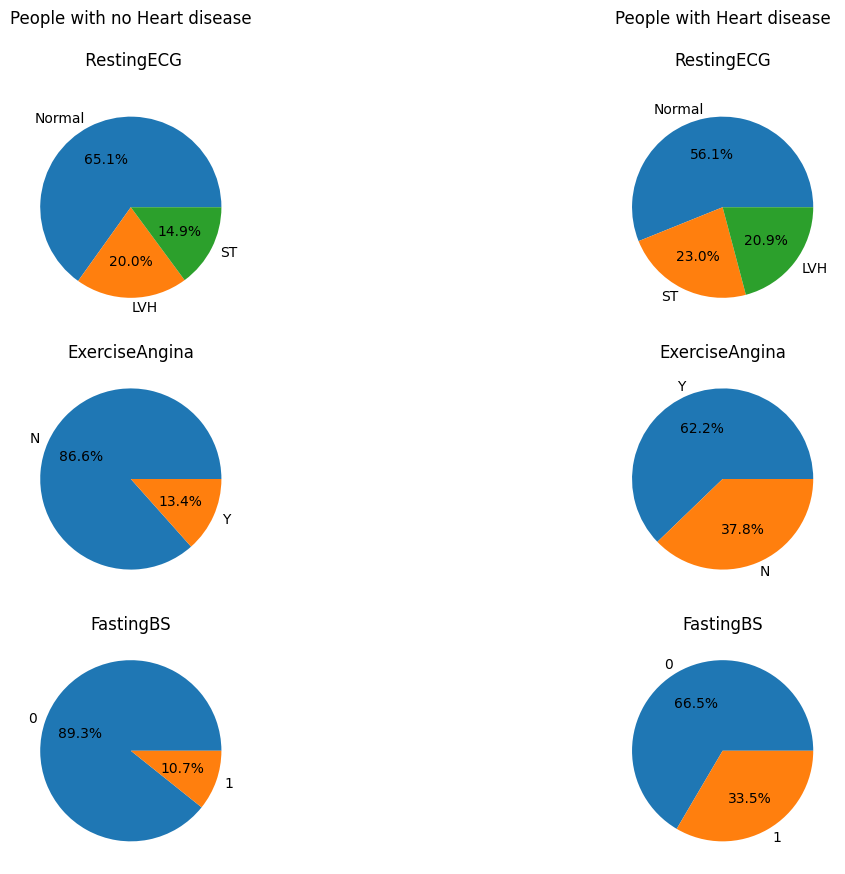

In [11]:
fig,axs = plt.subplots(3,2,figsize = (14,10))
axs[0, 0].pie( df[df.HeartDisease == 0]['RestingECG'].value_counts(), labels= df[df.HeartDisease == 0]['RestingECG'].value_counts().index, autopct='%1.1f%%')
axs[0, 1].pie( df[df.HeartDisease == 1]['RestingECG'].value_counts(), labels= df[df.HeartDisease == 1]['RestingECG'].value_counts().index, autopct='%1.1f%%')
axs[0,0].set_title("People with no Heart disease\n\n RestingECG\n")
axs[0,1].set_title("People with Heart disease\n\nRestingECG\n")
axs[1, 0].pie( df[df.HeartDisease == 0]['ExerciseAngina'].value_counts(), labels= df[df.HeartDisease == 0]['ExerciseAngina'].value_counts().index, autopct='%1.1f%%')
axs[1,0].set_title("ExerciseAngina")
axs[1, 1].pie( df[df.HeartDisease == 1]['ExerciseAngina'].value_counts(), labels= df[df.HeartDisease == 1]['ExerciseAngina'].value_counts().index, autopct='%1.1f%%')
axs[1,1].set_title("ExerciseAngina")
axs[2, 0].pie( df[df.HeartDisease == 0]['FastingBS'].value_counts(), labels= df[df.HeartDisease == 0]['FastingBS'].value_counts().index, autopct='%1.1f%%')
axs[2,0].set_title("FastingBS")
axs[2, 1].pie( df[df.HeartDisease == 1]['FastingBS'].value_counts(), labels= df[df.HeartDisease == 1]['FastingBS'].value_counts().index, autopct='%1.1f%%')
axs[2,1].set_title("FastingBS")

<Axes: xlabel='RestingBP', ylabel='Count'>

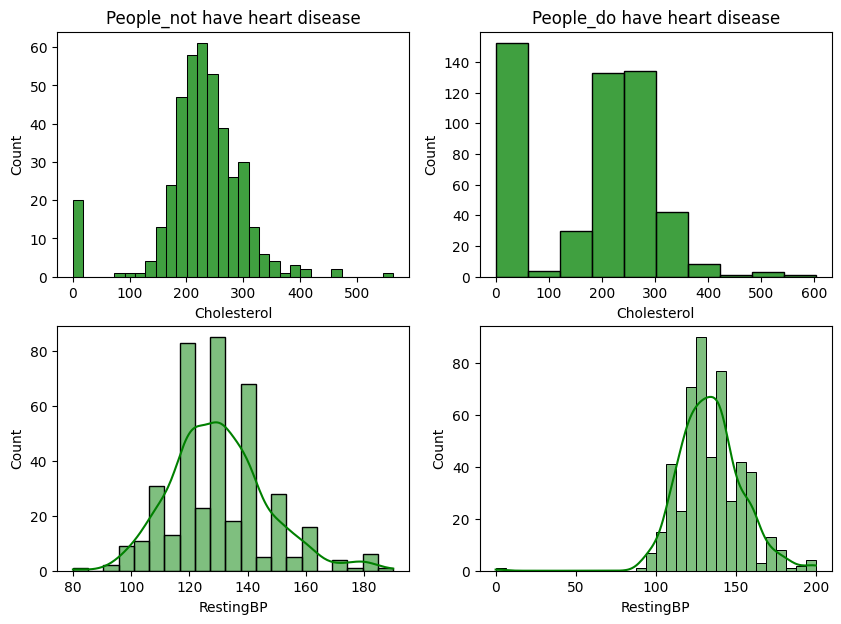

In [12]:
fig,axs = plt.subplots(2,2,figsize = (10,7))
sns.histplot(df[df.HeartDisease ==0].Cholesterol,ax = axs[0,0],color = 'green')
axs[0,0].set_title("People_not have heart disease")
sns.histplot(df[df.HeartDisease ==1].Cholesterol,ax = axs[0,1],color = 'green')
axs[0,1].set_title("People_do have heart disease")
sns.histplot(df[df.HeartDisease ==0].RestingBP,ax = axs[1,0],kde = True,color = 'green')
sns.histplot(df[df.HeartDisease ==1].RestingBP,ax = axs[1,1],kde = True,color = 'green')

In [13]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
  le=LabelEncoder()
  df[column] = le.fit_transform(df[column])
  label_encoders[column] = le

In [14]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    int64  
 2   ChestPainType   918 non-null    int64  
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    int64  
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    int64  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int64  
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 86.2 KB


In [16]:
x=df.drop('HeartDisease', axis=1).values.reshape(-1,1)
y=df['HeartDisease'].values.reshape(-1,1)

In [18]:
item=['RestingBP','Cholesterol']
for i in range(len(item)):
    print(f'nl \n ',df[item[i]].nlargest(3))
    print(f'ns \n ',df[item[i]].nsmallest(3))

nl 
  241    200
365    200
399    200
Name: RestingBP, dtype: int64
ns 
  449     0
314    80
227    92
Name: RestingBP, dtype: int64
nl 
  149    603
616    564
76     529
Name: Cholesterol, dtype: int64
ns 
  293    0
294    0
295    0
Name: Cholesterol, dtype: int64


In [19]:
print(f'nl \n ',df['MaxHR'].nlargest(3))
print(f'ns \n ',df['MaxHR'].nsmallest(3))

nl 
  829    202
759    195
795    194
Name: MaxHR, dtype: int64
ns 
  390    60
370    63
402    67
Name: MaxHR, dtype: int64


In [21]:
print(df.dtypes)


Age                 int64
Sex                 int64
ChestPainType       int64
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG          int64
MaxHR               int64
ExerciseAngina      int64
Oldpeak           float64
ST_Slope            int64
HeartDisease        int64
dtype: object


In [23]:
df['RestingBP'] = pd.to_numeric(df['RestingBP'], errors='coerce')
df['Cholesterol'] = pd.to_numeric(df['Cholesterol'], errors='coerce')

In [24]:
df['RestingBP']=df['RestingBP'].apply(lambda x: np.nan if x > 140 else x)
df['RestingBP']=df['RestingBP'].apply(lambda x: np.nan if x < 40 else x)
df['Cholesterol']=df['Cholesterol'].replace(0,np.nan)

In [25]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,221
Cholesterol,172
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [26]:
df['RestingBP']=df['RestingBP'].replace(np.nan,df['RestingBP'].median())
df['Cholesterol']=df['Cholesterol'].replace(np.nan,df['Cholesterol'].median())

In [27]:
df.isna().sum()


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [31]:
X=df.drop('HeartDisease',axis=1)
y=df['HeartDisease']

In [32]:
X

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2
1,49,0,2,126.0,180.0,0,1,156,0,1.0,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1
4,54,1,2,126.0,195.0,0,1,122,0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,3,110.0,264.0,0,1,132,0,1.2,1
914,68,1,0,126.0,193.0,1,1,141,0,3.4,1
915,57,1,0,130.0,131.0,0,1,115,1,1.2,1
916,57,0,1,130.0,236.0,0,0,174,0,0.0,1


In [33]:
y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
913,1
914,1
915,1
916,1


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.1, random_state = 1)

In [46]:
clf=LogisticRegression(max_iter=320, solver='newton-cg')

In [47]:
clf.fit(X_train,Y_train)

LogisticRegression(max_iter=320, solver='newton-cg')

In [48]:
y_pred=clf.predict(X_test)

In [50]:
clf.score(x,y)

0.8529411764705882

In [49]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93        37
           1       0.96      0.95      0.95        55

    accuracy                           0.95        92
   macro avg       0.94      0.95      0.94        92
weighted avg       0.95      0.95      0.95        92



In [51]:
LOAC=metrics.accuracy_score(Y_test,y_pred)

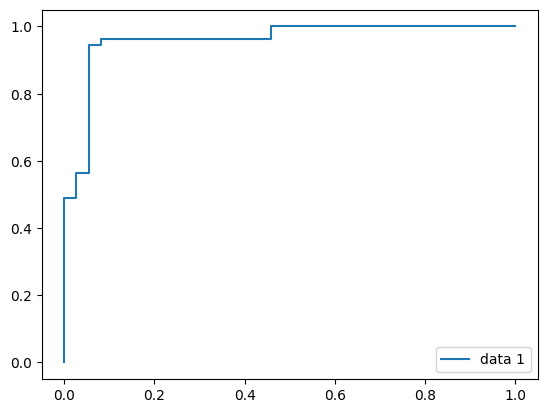

In [52]:
y_pred_proba = clf.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(Y_test,  y_pred_proba)
plt.plot(fpr,tpr,label="data 1")
plt.legend(loc=4)
plt.show()

In [53]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
k=20
acc=np.zeros((k))
for i in range (1,k+1):
    nclf=KNeighborsClassifier(n_neighbors=i)
    nclf.fit(X_train,Y_train)
    ny_pred=nclf.predict(X_test)
    acc[i-1]=metrics.accuracy_score(Y_test,ny_pred)
acc

array([0.76086957, 0.7173913 , 0.75      , 0.68478261, 0.70652174,
       0.69565217, 0.7173913 , 0.68478261, 0.76086957, 0.7173913 ,
       0.70652174, 0.68478261, 0.69565217, 0.68478261, 0.75      ,
       0.68478261, 0.72826087, 0.68478261, 0.72826087, 0.68478261])

In [55]:
acc.max()

np.float64(0.7608695652173914)

In [56]:
nclf=KNeighborsClassifier(n_neighbors=9)
nclf.fit(X_train,Y_train)
ny_pred=nclf.predict(X_test)
KNAC=metrics.accuracy_score(Y_test,ny_pred)

In [57]:
print(classification_report(Y_test,ny_pred))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70        37
           1       0.80      0.80      0.80        55

    accuracy                           0.76        92
   macro avg       0.75      0.75      0.75        92
weighted avg       0.76      0.76      0.76        92



In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [59]:
dtclf=DecisionTreeClassifier(max_depth=3)
dtclf.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=3)

In [60]:
dty_pred=dtclf.predict(X_test)

In [61]:
DTAC=metrics.accuracy_score(Y_test,dty_pred)

In [62]:
from sklearn import tree

In [63]:
text_representation=tree.export_text(dtclf)
print(text_representation)

|--- feature_10 <= 1.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_1 <= 0.50
|   |   |   |--- class: 1
|   |   |--- feature_1 >  0.50
|   |   |   |--- class: 1
|   |--- feature_2 >  0.50
|   |   |--- feature_7 <= 151.00
|   |   |   |--- class: 1
|   |   |--- feature_7 >  151.00
|   |   |   |--- class: 0
|--- feature_10 >  1.50
|   |--- feature_2 <= 0.50
|   |   |--- feature_9 <= 0.45
|   |   |   |--- class: 0
|   |   |--- feature_9 >  0.45
|   |   |   |--- class: 1
|   |--- feature_2 >  0.50
|   |   |--- feature_9 <= 2.20
|   |   |   |--- class: 0
|   |   |--- feature_9 >  2.20
|   |   |   |--- class: 1



In [65]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

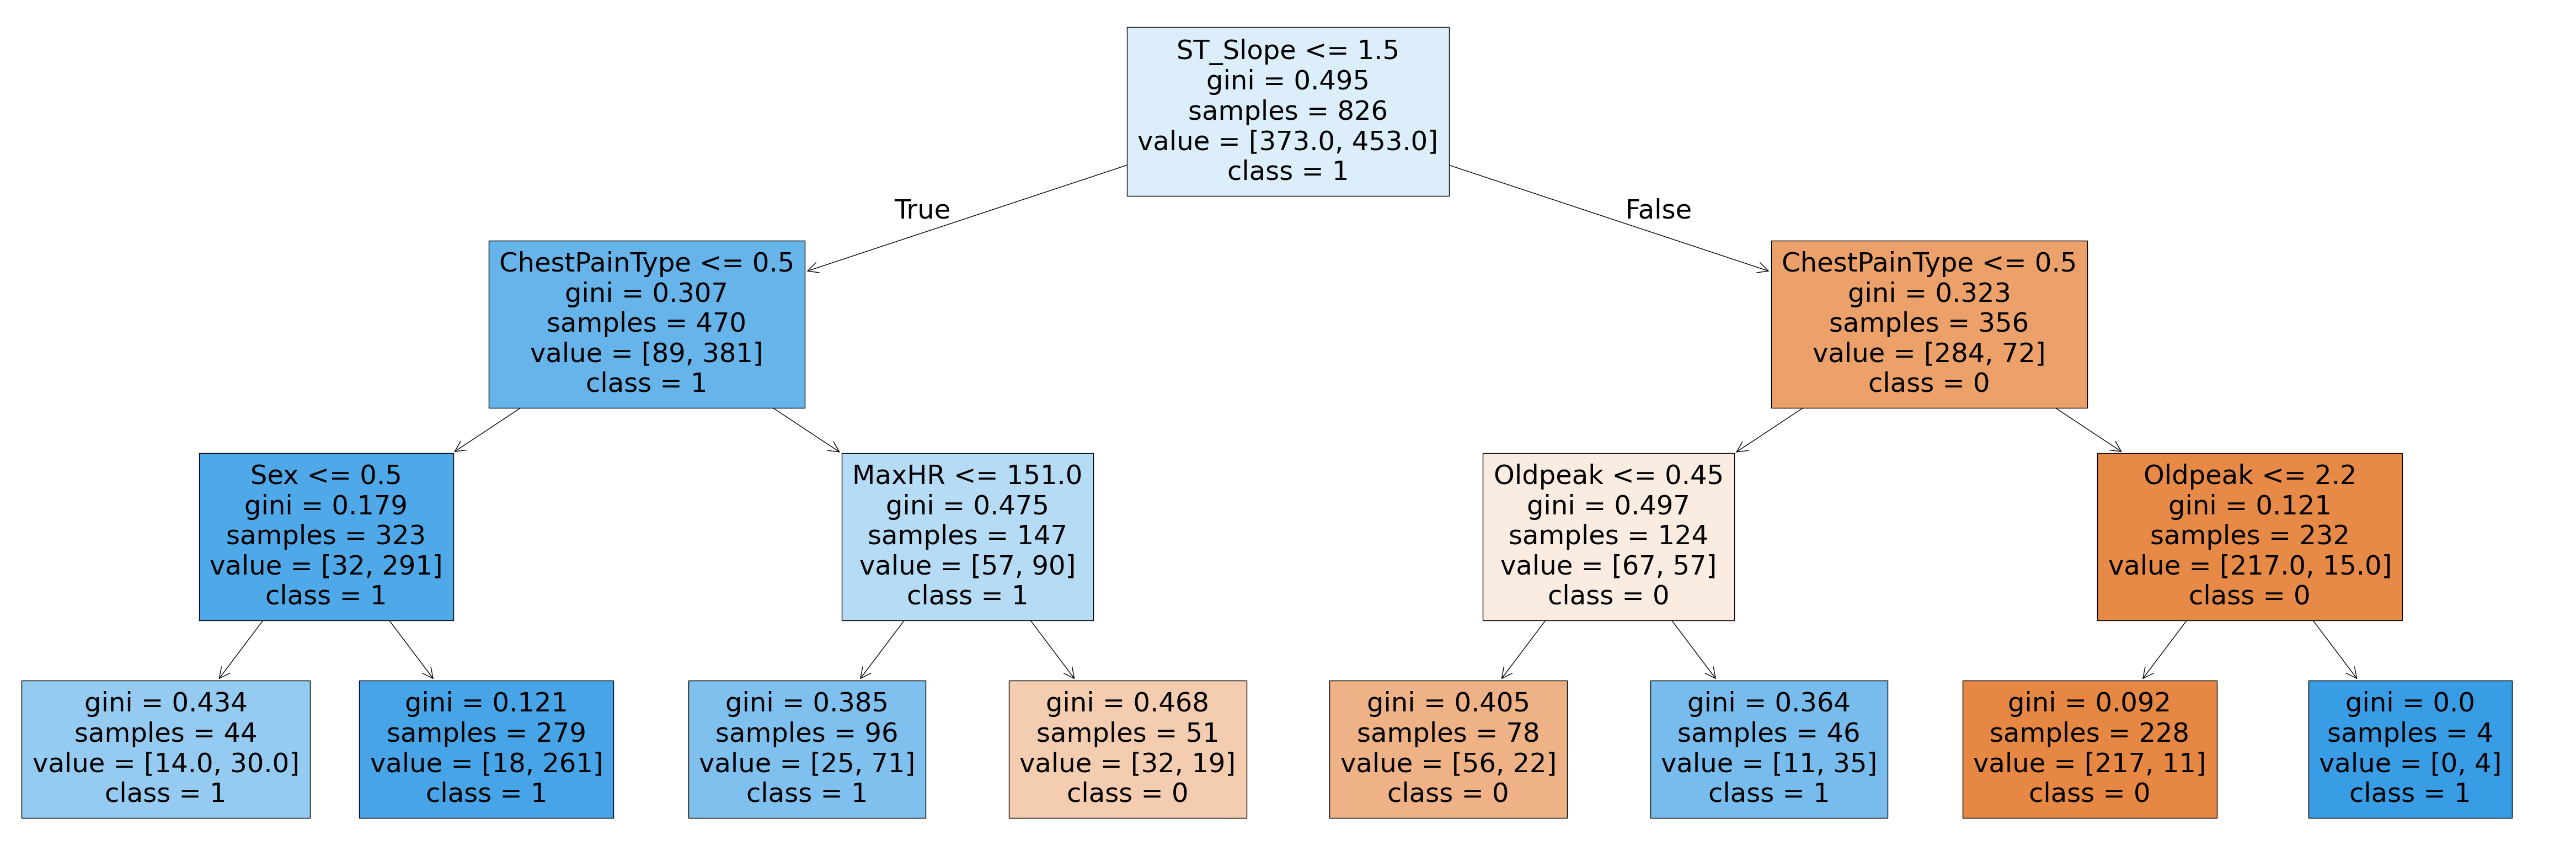

In [66]:
f_n=["Age","Sex","ChestPainType","RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak",'ST_Slope']
t_n=["0","1"]
fig=plt.figure(figsize=(60,20),dpi=100)
plot=tree.plot_tree(dtclf,feature_names=f_n,class_names=t_n,filled=True)
plt.show()

In [67]:
rfclf=RandomForestClassifier(n_estimators=160,max_depth=5,random_state=110)
rfclf.fit(X_train,Y_train)

RandomForestClassifier(max_depth=5, n_estimators=160, random_state=110)

In [68]:
rfy_pred=rfclf.predict(X_test)

In [69]:
RFAC=metrics.accuracy_score(Y_test,rfy_pred)

In [70]:
print(classification_report(Y_test,rfy_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        37
           1       0.96      0.96      0.96        55

    accuracy                           0.96        92
   macro avg       0.95      0.95      0.95        92
weighted avg       0.96      0.96      0.96        92



In [71]:
from sklearn.svm import SVC

In [72]:
svcclf=SVC(kernel='linear')
svcclf.fit(X_train,Y_train)

SVC(kernel='linear')

In [73]:
svcy_pred=svcclf.predict(X_test)
svcAC=metrics.accuracy_score(Y_test,svcy_pred)
svcAC

0.9565217391304348

In [75]:
compar=pd.DataFrame(columns=["algorithm","Accuracy"])
compar.loc[len(compar)] = ['LogisticRegression', LOAC]
compar.loc[len(compar)] = ['KNeighborsClassifier', KNAC]
compar.loc[len(compar)] = ['DecisionTreeClassifier', DTAC]
compar.loc[len(compar)] = ['RandomForestClassifier', RFAC]
compar.loc[len(compar)] = ['svc', svcAC]

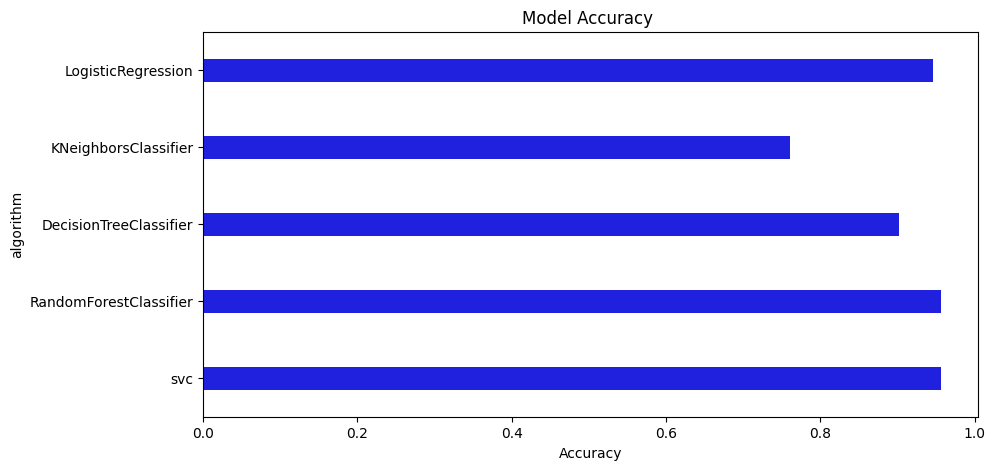

In [76]:
plt.figure(figsize=[10,5])
plt.title('Model Accuracy ')
sns.barplot(x='Accuracy', y='algorithm', data=compar ,width=0.3,color='blue')
plt.show()

In [77]:
compar

,algorithm,Accuracy
0,LogisticRegression,0.945652
1,KNeighborsClassifier,0.760870
2,DecisionTreeClassifier,0.902174
3,RandomForestClassifier,0.956522
4,svc,0.956522
